### RaschPy matrix MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the matrix parameterisation, each rater has a full, independent severity for every item x threshold combination — the most flexible (and most heavily parameterised) of the five rater representations.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Matrix(no_of_items=8, no_of_persons=40, no_of_raters=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:341: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_52699/2151788252.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set.

In [4]:
sim = rp.MFRM_Sim_Matrix(no_of_items=8, no_of_persons=200, no_of_raters=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_matrix_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_matrix_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     4.0     4.0     3.0     0.0     3.0     2.0     0.0   
        Person_2     2.0     2.0     3.0     0.0     3.0     1.0     2.0   

                  Item_8  
Rater   Person            
Rater_1 Person_1     3.0  
        Person_2     2.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater,Person,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the matrix parameterisation (a full, independent severity per rater x item x threshold combination). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_matrix()

CPU times: user 4.85 ms, sys: 281 μs, total: 5.13 ms
Wall time: 5.04 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1   -0.996183
Item_2   -0.391694
dtype: float64

Since this is simulated data, we know the true generating item locations and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery — alongside the Pearson correlation, SD ratio, regression coefficient, and RMSE. Recovery for the rater severities will be noisier than the other parameterisations (see below), since the matrix model spreads the same amount of data across many more free parameters (a severity for every rater x item x threshold cell):

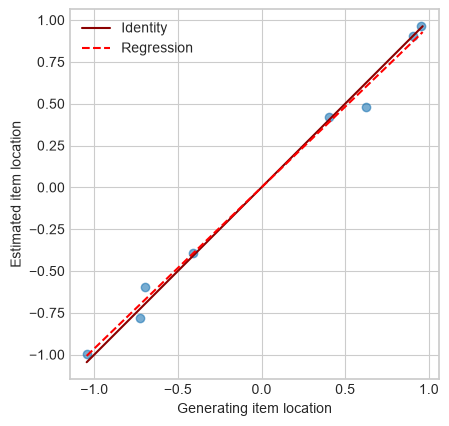

item location Pearson correlation:              0.997
item location SD ratio (estimated / generating): 0.967
item location regression coefficient:            0.964
item location RMSE:                              0.067


In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')

recovery_plot(sim.items, mfrm.items, 'item location', 'my_mfrm_matrix_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [12]:
%%time
mfrm.item_stats_df_matrix()
mfrm.item_stats_matrix.to_csv('mfrm_matrix_item_stats.csv')

CPU times: user 4.23 s, sys: 58.3 ms, total: 4.29 s
Wall time: 4.29 s


Check the item statistics table - view the first two items

In [13]:
mfrm.item_stats_matrix.head(2)

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
Item_1,-0.996,0.051,1600,0.653,0.911,0.907
Item_2,-0.392,0.031,1600,0.573,0.946,0.957


Generate a table of threshold statistics (and check run time), and save to file

In [14]:
%%time
mfrm.threshold_stats_df_matrix()
mfrm.threshold_stats_matrix.to_csv('mfrm_matrix_threshold_stats.csv')

CPU times: user 58.1 ms, sys: 2.01 ms, total: 60.1 ms
Wall time: 59.3 ms


Check the threshold statistics table - view the first two thresholds

In [15]:
mfrm.threshold_stats_matrix.head(2)

,Estimate,SE,Infit MS,Outfit MS
Threshold 1,-2.091,0.067,1.015,1.024
Threshold 2,-1.693,0.044,0.949,0.942


And the same recovery check for thresholds, against `sim.thresholds`:

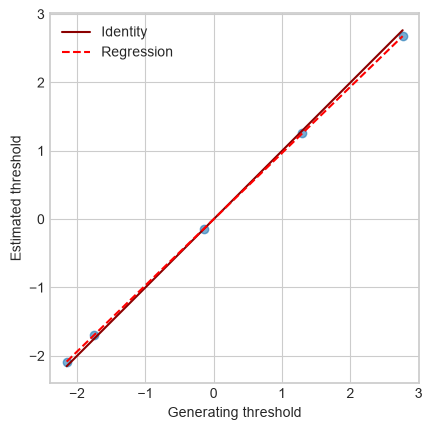

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 0.969
threshold regression coefficient:            0.969
threshold RMSE:                              0.058


In [16]:
recovery_plot(sim.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_matrix_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file. By default (`marginal=True`) this reports one row per rater, with item and threshold marginal severities. Pass `marginal=False` for the full (item, threshold) cell-level table instead.

In [17]:
%%time
mfrm.rater_stats_df_matrix()
mfrm.rater_stats_matrix.to_csv('mfrm_matrix_rater_stats.csv')

CPU times: user 33 ms, sys: 909 μs, total: 33.9 ms
Wall time: 33.8 ms


Check the rater statistics table - view the first two raters

In [18]:
mfrm.rater_stats_matrix.head(2)

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1   -0.376  0.175   -0.052  0.137   -0.143  0.138    0.183  0.199   
Rater_2   -0.494  0.155   -0.136  0.175   -0.107  0.146   -0.184  0.165   

          Item_5         ... Threshold 2 Threshold 3        Threshold 4  \
        Estimate     SE  ...          SE    Estimate     SE    Estimate   
Rater_1    0.080  0.178  ...       0.125      -0.124  0.078       0.240   
Rater_2   -0.044  0.137  ...       0.116       0.104  0.082      -0.271   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.110      -0.335  0.169             1600.0    0.937     0.933  
Rater_2  0.096      -0.129  0.205             1600.0    0.923     0.914  

[2 rows x 29 columns]

And the same recovery check for the full rater x item x threshold severities, against `sim.facet_effects`. Since these are per rater x item x threshold, we flatten with `.stack()` first — expect this to be the noisiest of the recovery plots, for the reason noted above:

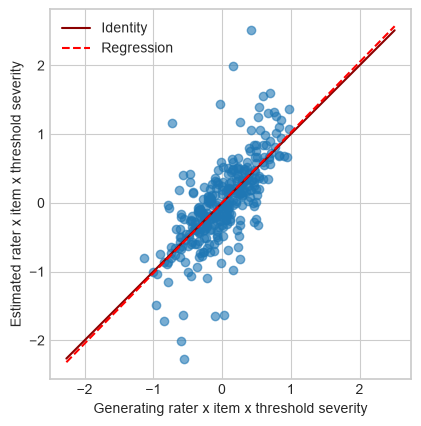

rater x item x threshold severity Pearson correlation:              0.703
rater x item x threshold severity SD ratio (estimated / generating): 1.456
rater x item x threshold severity regression coefficient:            1.024
rater x item x threshold severity RMSE:                              0.437


In [19]:
orig_severities = sim.facet_effects.stack()
est_severities = mfrm.raters_matrix.stack()
recovery_plot(orig_severities, est_severities, 'rater x item x threshold severity', 'my_mfrm_matrix_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [20]:
%%time
mfrm.person_stats_df_matrix()
mfrm.person_stats_matrix.to_csv('mfrm_matrix_person_stats.csv')

CPU times: user 10.1 ms, sys: 532 μs, total: 10.7 ms
Wall time: 10.6 ms


Check the person statistics table - view the first two persons

In [21]:
mfrm.person_stats_matrix.head(2)

,Estimate,CSEM,Score,Max score,p,Infit MS,Outfit MS
Person_1,0.377,0.148,184,320,0.575,1.030,1.012
Person_2,-1.542,0.144,90,320,0.281,1.025,0.968


And the same recovery check for person locations, against `sim.persons`:

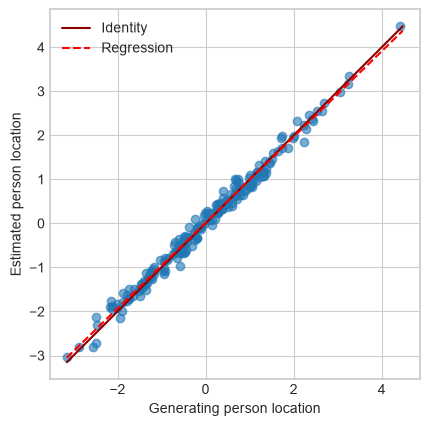

person location Pearson correlation:              0.994
person location SD ratio (estimated / generating): 0.979
person location regression coefficient:            0.973
person location RMSE:                              0.146


In [22]:
recovery_plot(sim.persons, mfrm.persons_matrix, 'person location', 'my_mfrm_matrix_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [23]:
%%time
mfrm.test_stats_df_matrix()
mfrm.test_stats_matrix.to_csv('mfrm_matrix_test_stats.csv')

CPU times: user 2.02 ms, sys: 395 μs, total: 2.41 ms
Wall time: 2.42 ms


Check the test statistics table

In [24]:
mfrm.test_stats_matrix

,Items,Persons
Mean,0.000,0.017
SD,0.781,1.295
Separation ratio,19.667,8.692
Strata,26.556,11.923
Reliability,0.997,0.987


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [25]:
%%time
mfrm.item_res_corr_analysis_matrix()
mfrm.item_residual_correlations_matrix.to_csv('mfrm_matrix_item_residual_correlations.csv')
mfrm.item_loadings_matrix.to_csv('mfrm_matrix_item_loadings.csv')

CPU times: user 4.33 ms, sys: 1.4 ms, total: 5.74 ms
Wall time: 6.43 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [26]:
mfrm.item_residual_correlations_matrix

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Item_1,1.000000,0.018444,-0.012537,-0.040253,-0.002010,-0.031645,-0.072735,-0.005627
Item_2,0.018444,1.000000,0.006348,-0.007755,-0.041175,-0.019457,-0.034753,0.013502
Item_3,-0.012537,0.006348,1.000000,-0.006580,-0.009278,0.015784,-0.027978,0.009807
Item_4,-0.040253,-0.007755,-0.006580,1.000000,0.071550,-0.029710,-0.009133,-0.045252
Item_5,-0.002010,-0.041175,-0.009278,0.071550,1.000000,-0.043623,-0.015545,0.018780
Item_6,-0.031645,-0.019457,0.015784,-0.029710,-0.043623,1.000000,-0.049228,-0.009356
Item_7,-0.072735,-0.034753,-0.027978,-0.009133,-0.015545,-0.049228,1.000000,-0.000180
Item_8,-0.005627,0.013502,0.009807,-0.045252,0.018780,-0.009356,-0.000180,1.000000


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [27]:
mfrm.item_loadings_matrix['PC 1']

Item_1   -0.146366
Item_2   -0.140567
Item_3   -0.081677
Item_4    0.216388
Item_5    0.197663
Item_6   -0.135893
Item_7    0.155177
Item_8   -0.059773
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [28]:
%%time
mfrm.rater_res_corr_analysis_matrix()
mfrm.rater_residual_correlations_matrix.to_csv('mfrm_matrix_rater_residual_correlations.csv')
mfrm.rater_loadings_matrix.to_csv('mfrm_matrix_rater_loadings.csv')

CPU times: user 7.89 ms, sys: 659 μs, total: 8.55 ms
Wall time: 8.56 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [29]:
mfrm.rater_residual_correlations_matrix

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000000,-0.046424,-0.004498,-0.044294,-0.012944,-0.024000,-0.010932,-0.010267
Rater_2,-0.046424,1.000000,-0.000550,0.005009,-0.036700,-0.032505,-0.014954,-0.033185
Rater_3,-0.004498,-0.000550,1.000000,-0.042873,-0.007447,-0.006092,-0.054992,0.032014
Rater_4,-0.044294,0.005009,-0.042873,1.000000,-0.055428,0.008135,0.002115,-0.001142
Rater_5,-0.012944,-0.036700,-0.007447,-0.055428,1.000000,0.015525,-0.055602,0.030664
Rater_6,-0.024000,-0.032505,-0.006092,0.008135,0.015525,1.000000,0.028629,-0.029193
Rater_7,-0.010932,-0.014954,-0.054992,0.002115,-0.055602,0.028629,1.000000,-0.001324
Rater_8,-0.010267,-0.033185,0.032014,-0.001142,0.030664,-0.029193,-0.001324,1.000000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [30]:
mfrm.rater_loadings_matrix['PC 1']

Rater_1   -0.116716
Rater_2    0.109569
Rater_3   -0.155913
Rater_4    0.206861
Rater_5   -0.194201
Rater_6    0.099395
Rater_7    0.163178
Rater_8   -0.124194
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

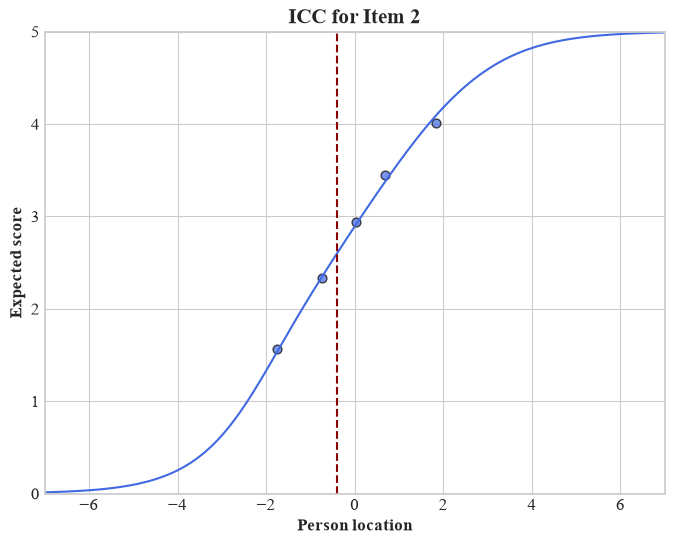

In [31]:
mfrm.icc_matrix('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_matrix_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

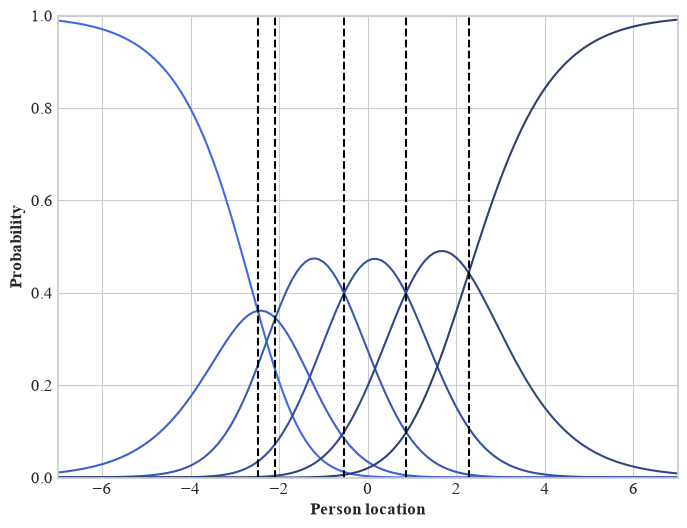

In [32]:
mfrm.crcs_matrix('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_matrix_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

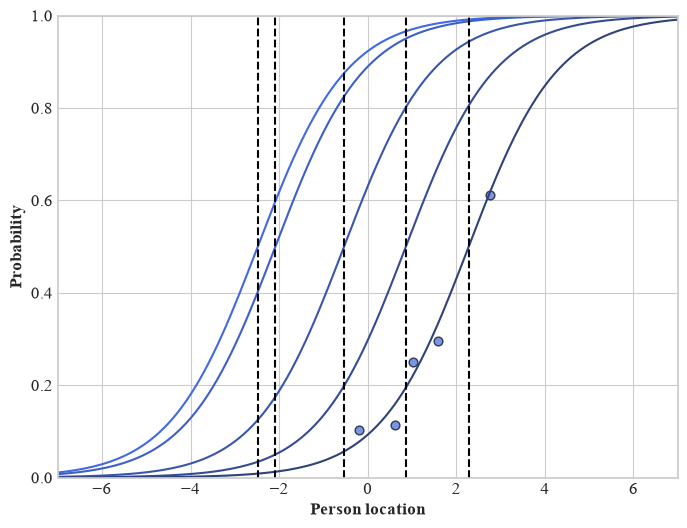

In [33]:
mfrm.threshold_ccs_matrix('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_matrix_threshold_ccs')

Produce an item information function curve for Item 2

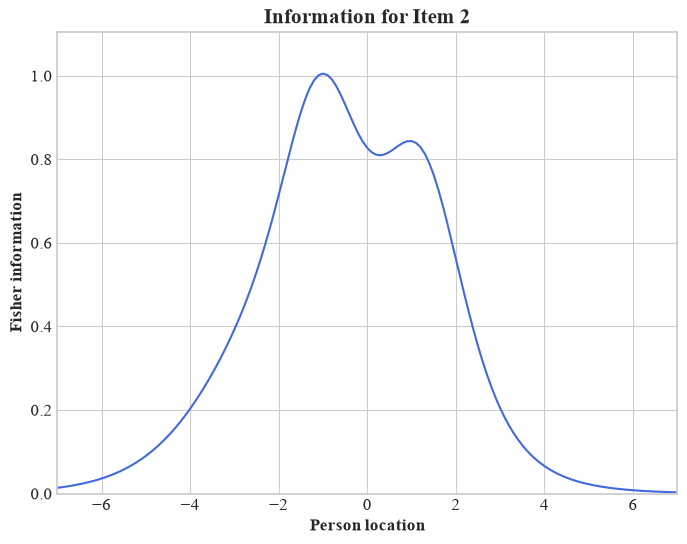

In [34]:
mfrm.iic_matrix('Item_2', title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_matrix_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 20 and 30 plotted.

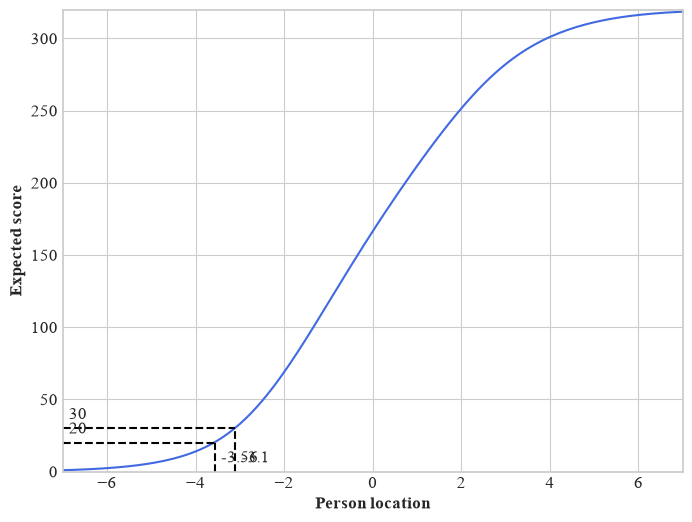

In [35]:
mfrm.tcc_matrix(score_lines=[20, 30], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_matrix_tcc')

Produce a test information curve

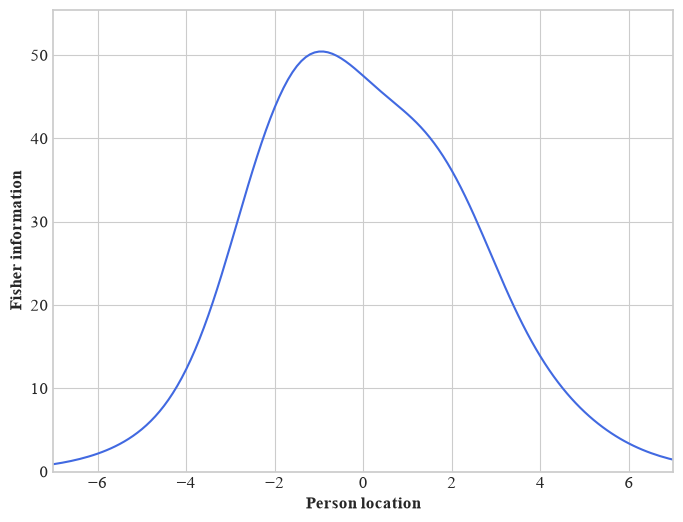

In [36]:
mfrm.test_info_matrix(xmin=-7, xmax=7, filename='my_mfrm_matrix_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

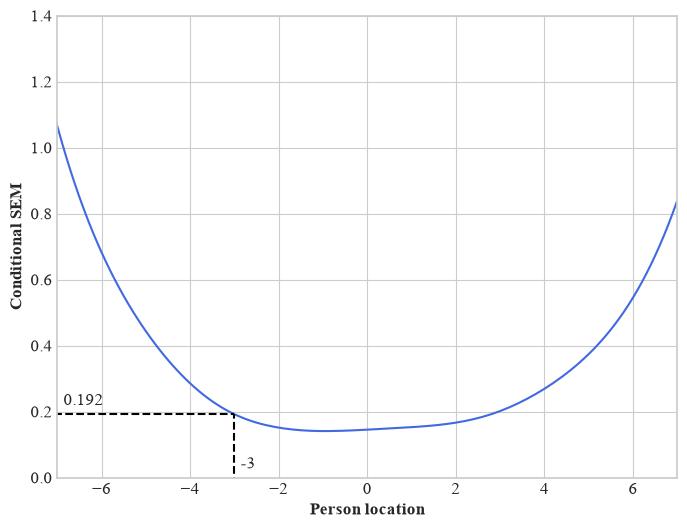

In [37]:
mfrm.test_csem_matrix(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_matrix_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

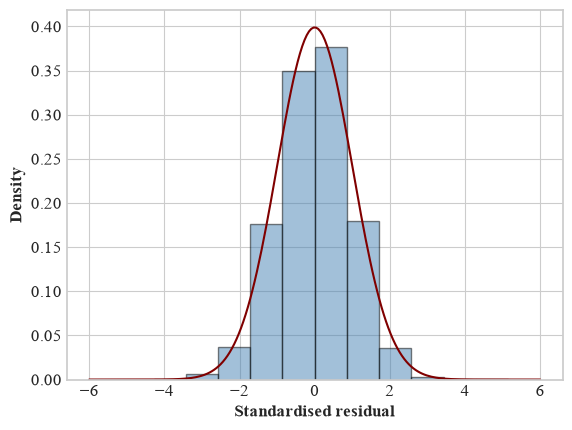

In [38]:
mfrm.std_residuals_plot_matrix(bin_width=0.6, normal=True, filename='my_mfrm_matrix_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [39]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_matrix_anchor(anchors)

CPU times: user 1.25 ms, sys: 207 μs, total: 1.45 ms
Wall time: 1.34 ms


Check the anchored item locations against the unanchored ones.

In [40]:
mfrm.items

Item_1   -0.996183
Item_2   -0.391694
Item_3   -0.598730
Item_4    0.902859
Item_5   -0.781081
Item_6    0.419399
Item_7    0.963101
Item_8    0.482329
dtype: float64

In [41]:
mfrm.anchor_items_matrix

Item_1   -0.983231
Item_2   -0.411066
Item_3   -0.727437
Item_4    1.039186
Item_5   -0.717390
Item_6    0.317748
Item_7    0.874135
Item_8    0.608055
dtype: float64

Check the anchored thresholds against the unanchored thresholds

In [42]:
mfrm.thresholds

1   -2.090738
2   -1.693424
3   -0.141943
4    1.253389
5    2.672717
dtype: float64

In [43]:
mfrm.anchor_thresholds_matrix

1   -2.167764
2   -1.565541
3   -0.089977
4    1.278526
5    2.544756
dtype: float64

Check the anchored marginal item severities against the unanchored ones

In [44]:
mfrm.marginal_raters_items

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater_1,-0.376144,-0.052295,-0.142954,0.182784,0.079544,-0.037537,-0.076090,0.292076
Rater_2,-0.494217,-0.136221,-0.107362,-0.184438,-0.044227,-0.347662,-0.079452,0.637954
Rater_3,0.527427,-0.050060,-0.017090,-0.096407,0.210329,-0.075310,-0.238680,-0.387477
Rater_4,0.324530,0.090874,-0.317639,0.573156,-0.061094,-0.016307,-0.031854,-0.109866
Rater_5,0.206129,0.210571,0.168641,0.124909,0.260621,0.471496,0.041774,-0.274911
Rater_6,-0.133713,-0.308126,0.526713,-0.061348,-0.058371,0.318911,0.043007,-0.148056
Rater_7,-0.117494,0.157950,0.003503,-0.144688,-0.307978,-0.511180,0.168559,0.296791
Rater_8,0.063480,0.087307,-0.113814,-0.393968,-0.078825,0.197590,0.172737,-0.306512


In [45]:
mfrm.anchor_marginal_raters_items

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater_1,-0.371543,-0.015370,0.003307,0.064010,0.033406,0.081667,0.030429,0.183904
Rater_2,-0.489616,-0.099295,0.038899,-0.303212,-0.090365,-0.228458,0.027067,0.529782
Rater_3,0.532028,-0.013135,0.129171,-0.215181,0.164191,0.043894,-0.132161,-0.495649
Rater_4,0.329131,0.127799,-0.171378,0.454382,-0.107232,0.102897,0.074665,-0.218038
Rater_5,0.210730,0.247497,0.314902,0.006135,0.214483,0.590700,0.148293,-0.383083
Rater_6,-0.129112,-0.271201,0.672974,-0.180122,-0.104509,0.438116,0.149526,-0.256228
Rater_7,-0.112893,0.194876,0.149764,-0.263461,-0.354116,-0.391976,0.275078,0.188619
Rater_8,0.068081,0.124232,0.032447,-0.512741,-0.124963,0.316794,0.279256,-0.414684


Check the anchored marginal threshold severities against the unanchored ones

In [46]:
mfrm.marginal_raters_thresholds

,1,2,3,4,5
Rater_1,-0.094769,0.231768,-0.124047,0.240465,-0.335052
Rater_2,-0.159242,-0.017229,0.104053,-0.270577,-0.129271
Rater_3,0.231504,0.185324,0.039712,-0.019440,-0.516642
Rater_4,-0.355807,0.041455,0.117935,0.079885,0.398908
Rater_5,-0.044905,0.264215,0.144742,0.063368,0.328349
Rater_6,0.295923,-0.337311,-0.031319,0.087715,0.096878
Rater_7,-0.113626,-0.001574,-0.073013,-0.089256,-0.006615
Rater_8,0.240921,-0.366649,-0.178063,-0.092159,0.163445


In [47]:
mfrm.anchor_marginal_raters_thresholds

,1,2,3,4,5
Rater_1,-0.001417,0.120212,-0.159686,0.231655,-0.190764
Rater_2,0.012236,-0.050659,0.146539,-0.201260,0.093143
Rater_3,0.324437,0.073350,0.003654,-0.028668,-0.372773
Rater_4,-0.335257,-0.142903,0.009493,-0.001727,0.470393
Rater_5,-0.119034,-0.014822,-0.058379,-0.112922,0.305156
Rater_6,0.350571,-0.487571,-0.105663,0.040201,0.202462
Rater_7,0.020216,-0.072640,-0.068163,-0.057576,0.178162
Rater_8,0.364447,-0.448031,-0.183528,-0.070795,0.337907
